In [2]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
%matplotlib widget


In [40]:
# returns GR_{i,j,t,t'}
def read_GR_hodlr(filename, name, t_max = -1):
    f = h5.File(filename)
    nao = f[name + '/size1'][()]
    nt = f[name + '/nt'][()]
    nbox = f[name + '/nbox'][()]
    r2_dir = f['geometry/r2_dir'][()]
    blkc1 = f['geometry/blkc1'][()]
    blkc2 = f['geometry/blkc2'][()]
    blkr1 = f['geometry/blkr1'][()]
    blkr2 = f['geometry/blkr2'][()]

    # t_max=-1 means read everything
    if(t_max==-1 or t_max > nt): 
        t_max = nt
    
    # size of G is decided by t_max
    GR_h = np.zeros((nao, nao, t_max, t_max), dtype = complex)
    
    # read in triangle parts
    ret_dir = f[name + '/ret/dirtricol'][()]
    count = 0
    for tp in np.arange(t_max):
        for t in np.arange(r2_dir[tp]-tp+1):
            if tp+t < t_max: GR_h[:,:,tp+t,tp] = ret_dir[count,:,:]
            count+=1

    for b in np.arange(nbox):
        for i in np.arange(nao):
            for j in np.arange(nao):
                dim1_s = blkr1[b]
                dim1_e = min(blkr2[b]+1,t_max)
                dim2_s = blkc1[b]
                dim2_e = min(blkc2[b]+1,t_max)
                if(dim1_s<t_max and dim2_s<t_max):
                    label = name + '/ret/' + str(b) + '_' + str(i) + '_' + str(j)
                    U = f[label+'/U'][()]
                    S = f[label+'/S'][()]
                    V = f[label+'/V'][()]
                    # t  goes from first row of block to last row of block (or t_max)
                    # t' goes from first col to last col (or t_max)
                    GR_h[i,j,dim1_s:dim1_e,dim2_s:dim2_e] = np.dot(np.dot(U[:(dim1_e-dim1_s),:], np.diag(S)), np.matrix.getH(V[:(dim2_e-dim2_s),:]))
    return GR_h

# returns GL_{i,j,t,t'}
def read_GL_hodlr(filename, name, t_max = -1):
    f = h5.File(filename)
    nao = f[name + '/size1'][()]
    nt = f[name + '/nt'][()]
    nbox = f[name + '/nbox'][()]
    ntri = f['geometry/ntri'][:]
    blkc1 = f['geometry/blkc1'][()]
    blkc2 = f['geometry/blkc2'][()]
    blkr1 = f['geometry/blkr1'][()]
    blkr2 = f['geometry/blkr2'][()]

    # t_max=-1 means read everything
    if(t_max==-1 or t_max > nt): 
        t_max = nt

    # size of G is decided by t_max
    GL_h = np.zeros((nao, nao, t_max, t_max), dtype = complex)

    # size of each diagonal square is given by maxima of ntri
    # last element is also a maximum
    sq_sizes = np.append(ntri[find_peaks(ntri)[0]], ntri[-1])

    # read in squares along diagonal.
    les_square = f[name + '/les/dir'][()]
    # i - index along les_square
    # s - index along diagonal, top left element of square
    i = 0
    s = 0
    for b in np.arange(nbox+1):
        e = s + sq_sizes[b]
        # block may be truncated by t_max, in which case we only need upper left portion
        e_block = min(e,t_max)
        # remember we are storing upper tri of GL - need to transpose result
        GL_h[:,:,s:e_block,s:e_block] = np.swapaxes(np.reshape(les_square[:,:,i:i+sq_sizes[b]**2],(nao,nao,sq_sizes[b],sq_sizes[b]))[:,:,:e_block-s,:e_block-s],-1,-2)
        i += sq_sizes[b]**2
        s += sq_sizes[b]
        if(s > t_max): break
    
    for b in np.arange(nbox):
        for i in np.arange(nao):
            for j in np.arange(nao):
                dim1_s = blkr1[b]
                dim1_e = min(blkr2[b]+1,t_max)
                dim2_s = blkc1[b]
                dim2_e = min(blkc2[b]+1,t_max)
                if(dim1_s<t_max and dim2_s<t_max):
                    label = name + '/les/' + str(b) + '_' + str(i) + '_' + str(j)
                    U = f[label+'/U'][()]
                    S = f[label+'/S'][()]
                    V = f[label+'/V'][()]
                    # remember we are storing upper tri part of GL - need to transpose result
                    # t (first time index) goes from first to last col
                    # t' (second time index) goes from first to last row
                    GL_h[i,j,dim2_s:dim2_e,dim1_s:dim1_e] = np.dot(np.dot(U[:(dim1_e-dim1_s),:], np.diag(S)), np.matrix.getH(V[:(dim2_e-dim2_s),:])).T
                    GL_h[i,j,dim1_s:dim1_e,dim2_s:dim2_e] = -GL_h[i,j,dim2_s:dim2_e,dim1_s:dim1_e].T.conj()
    return GL_h

def read_function_hodlr(filename, name):
    return h5.File(filename)[name][()]


In [64]:
# returns GR and GL arrays with indices [k,i,j,t,t']
# set t_final = -1 for entire G
t_final = -1
GR = [read_GR_hodlr("/path/to/GS/GSigma" + str(i) + ".h5", "G/", t_final) for i in np.arange(24)]
GL = [read_GL_hodlr("/path/to/GS/GSigma" + str(i) + ".h5", "G/", t_final) for i in np.arange(24)]

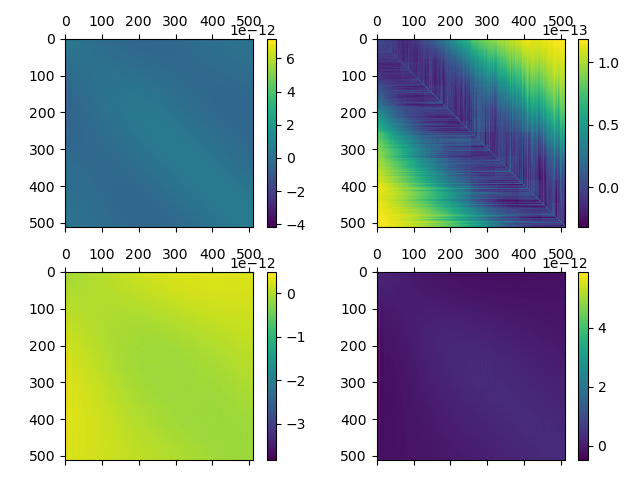

In [65]:
# visualize Lesser component at multiple k-points
fig, axs = plt.subplots(2, 2)
im0 = axs[0,0].matshow(GL[0][0,0,:,:].imag)
im1 = axs[0,1].matshow(GL[3][0,0,:,:].imag)
im2 = axs[1,0].matshow(GL[7][0,0,:,:].imag)
im3 = axs[1,1].matshow(GL[21][0,0,:,:].imag)

fig.colorbar(im0, ax=axs[0,0])
fig.colorbar(im1, ax=axs[0,1])
fig.colorbar(im2, ax=axs[1,0])
fig.colorbar(im3, ax=axs[1,1])

plt.tight_layout()
plt.show()


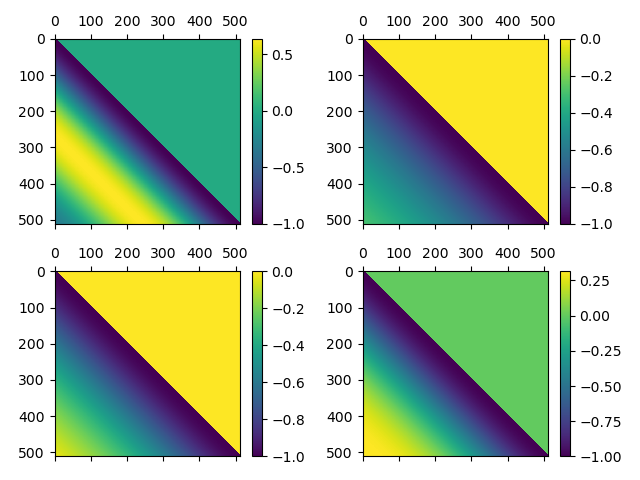

In [66]:
# visualize Retarded component at multiple k-points
fig, axs = plt.subplots(2, 2)
im0 = axs[0,0].matshow(GR[0][0,0,:,:].imag)
im1 = axs[0,1].matshow(GR[3][0,0,:,:].imag)
im2 = axs[1,0].matshow(GR[7][0,0,:,:].imag)
im3 = axs[1,1].matshow(GR[21][0,0,:,:].imag)

fig.colorbar(im0, ax=axs[0,0])
fig.colorbar(im1, ax=axs[0,1])
fig.colorbar(im2, ax=axs[1,0])
fig.colorbar(im3, ax=axs[1,1])

plt.tight_layout()
plt.show()


In [67]:
# read in the current
jxtnorm = read_function_hodlr("/path/to/obs.h5", "jxtnorm")

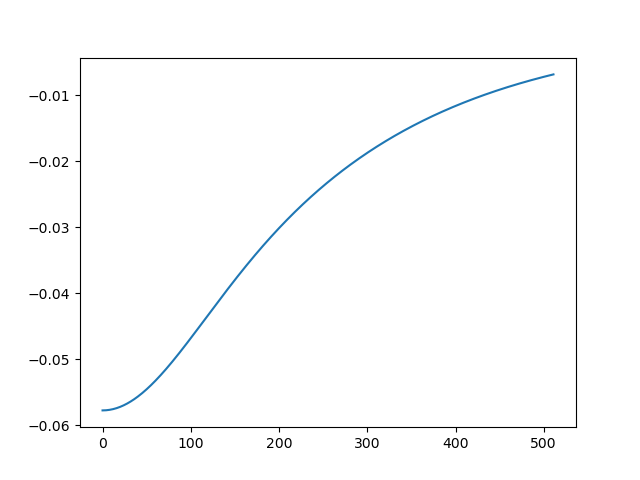

In [69]:
plt.figure()
plt.plot(jxtnorm)